Rows after fixing: 1001388
     cmte_id    cand_id             cand_nm           contbr_nm  \
0  C00410118  P20002978  Bachmann, Michelle     HARVEY, WILLIAM   
1  C00410118  P20002978  Bachmann, Michelle     HARVEY, WILLIAM   
2  C00410118  P20002978  Bachmann, Michelle       SMITH, LANIER   
3  C00410118  P20002978  Bachmann, Michelle    BLEVINS, DARONDA   
4  C00410118  P20002978  Bachmann, Michelle  WARDENBURG, HAROLD   

          contbr_city contbr_st contbr_zip        contbr_employer  \
0              MOBILE        AL  366010290                RETIRED   
1              MOBILE        AL  366010290                RETIRED   
2              LANETT        AL  368633403  INFORMATION REQUESTED   
3             PIGGOTT        AR  724548253                   NONE   
4  HOT SPRINGS NATION        AR  719016467                   NONE   

       contbr_occupation contb_receipt_amt($) contb_receipt_dt receipt_desc  \
0                RETIRED                  250        20-JUN-11              

/tmp/ipykernel_2162/1915185174.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['contb_receipt_dt'] = pd.to_datetime(df['contb_receipt_dt'], errors='coerce')


Valid amounts: 1001388
Rows after cleaning: 1001388


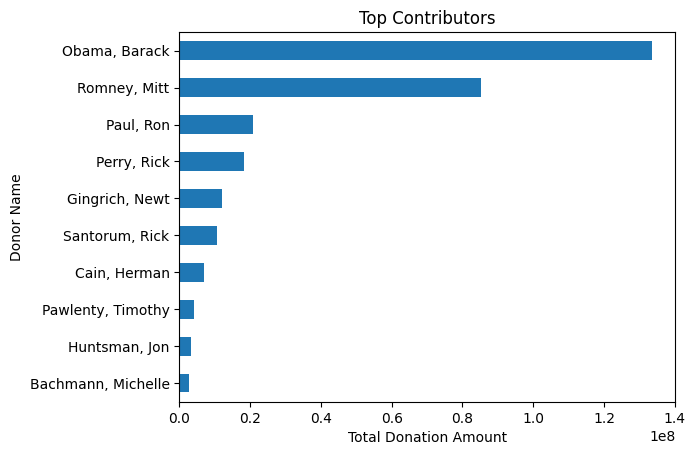


 top contributers:
 cand_nm
Obama, Barack         1.334702e+08
Romney, Mitt          8.513586e+07
Paul, Ron             2.071641e+07
Perry, Rick           1.840128e+07
Gingrich, Newt        1.200988e+07
Santorum, Rick        1.070777e+07
Cain, Herman          7.045795e+06
Pawlenty, Timothy     4.182756e+06
Huntsman, Jon         3.201450e+06
Bachmann, Michelle    2.676297e+06
Name: contb_receipt_amt($), dtype: float64

Occupation Stats:
                                          count        mean          sum
contbr_occupation                                                      
RETIRED                                 234819  205.084458  48157727.25
ATTORNEY                                 34405  536.819626  18469279.23
HOMEMAKER                                30189  578.541773  17465597.58
INFORMATION REQUESTED PER BEST EFFORTS   21358  742.049702  15848697.54
INFORMATION REQUESTED                    35175  248.524736   8741857.59
PHYSICIAN                                23515  307.01

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import csv



# fixing row structure which was broken

clean_rows = []


with open('/content/fec_data(in).csv', 'r', errors='ignore') as f:
    reader = csv.reader(f)

    # rows = list(reader)
    # print("rows before cleaning:", len(rows))

    next(reader)
    for each_row_in_file in reader:
        raw = each_row_in_file[0]
        raw = raw.replace(';;;;', '')
        fixed_row = list(csv.reader([raw]))[0]

        # if len(fixed_row) >= 16:
        #     clean_rows.append(fixed_row)
        if len(fixed_row) >= 16:
            fixed_row = fixed_row[:16]
            clean_rows.append(fixed_row)



#creating df

columns = [
    'cmte_id','cand_id','cand_nm','contbr_nm','contbr_city',
    'contbr_st','contbr_zip','contbr_employer','contbr_occupation',
    'contb_receipt_amt($)','contb_receipt_dt','receipt_desc',
    'memo_cd','memo_text','form_tp','file_num'
]

df = pd.DataFrame(clean_rows, columns=columns)


print("Rows after fixing:", len(df))
print(df.head())

#data types cleaning

df['contb_receipt_amt($)'] = pd.to_numeric(df['contb_receipt_amt($)'], errors='coerce')
df['contb_receipt_dt'] = pd.to_datetime(df['contb_receipt_dt'], errors='coerce')

df['contbr_employer'] = df['contbr_employer'].fillna('NOT PROVIDED')
df['contbr_occupation'] = df['contbr_occupation'].fillna('NOT PROVIDED')


#valid data filtering

print("Valid amounts:", df['contb_receipt_amt($)'].notna().sum())

df = df[df['contb_receipt_amt($)'].notna()]

print("Rows after cleaning:", len(df))


# Analysis started

# Top donors
top_donors = (df.groupby('cand_nm')['contb_receipt_amt($)'].sum().sort_values(ascending=False).head(10))

if top_donors.empty:
  print("nothing to plot")
else:
    plt.figure()
    top_donors.sort_values().plot(kind='barh')

    plt.title('Top Contributors')
    plt.xlabel('Total Donation Amount')
    plt.ylabel('Donor Name')
    plt.show()


# Top Candidates
top_candidates= df.groupby('cand_nm')['contb_receipt_amt($)'].sum().sort_values(ascending=False).head(10)
print("\n top contributers:\n",top_candidates)


# Occupation stats
occ_stats = df.groupby('contbr_occupation')['contb_receipt_amt($)'].agg(['count','mean','sum']).sort_values('sum', ascending=False)

print("\nOccupation Stats:\n", occ_stats.head(10))

# Employer stats
emp_stats = df.groupby('contbr_employer')['contb_receipt_amt($)'].agg(['count','sum']).sort_values('sum', ascending=False)

print("\nEmployer Stats:\n", emp_stats.head(10))

# State stats
state_stats = df.groupby('contbr_st')['contb_receipt_amt($)'].agg(['count','sum']).sort_values('sum', ascending=False)

print("\nState Stats:\n", state_stats.head(10))

# Top leader
leader_totals = df.groupby('cand_nm')['contb_receipt_amt($)'].sum().sort_values(ascending=False)

if not leader_totals.empty:
    print("\nTop Leader:", leader_totals.index[0])

# Sort by address
df_sorted = df.sort_values(by=['contbr_st','contbr_city'])

# State → Candidate
state_leader = df[['contbr_st','cand_nm']].drop_duplicates().sort_values('contbr_st')

print("\nState → Candidate:\n", state_leader.head(10))

# # creating to save version of ceaned file

# df.to_csv('/content/cleaned_fec_data.csv', index=False)

# print("\nCleaned file saved successfully!")


